# Module 6 - Alzheimer's: Patient Population

Demographics for the Alzheimer's cohort. Expected pattern: strongly elderly, mixed sex, caregiver / physician heavy reporting.

In [6]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

db_path = r"C:\Users\palla\OneDrive\Documents\Coding Projects\FDA_FAERS\database\faers.db"
conn = sqlite3.connect(db_path)

## Step 1 - Age distribution by drug class

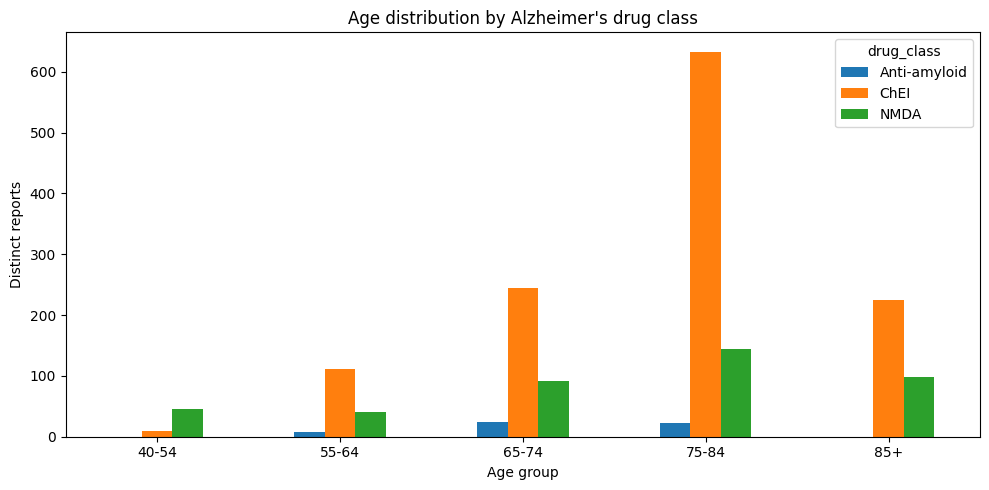

drug_class,Anti-amyloid,ChEI,NMDA
age_group,,,
40-54,0,9,46
55-64,7,111,40
65-74,24,244,92
75-84,23,633,145
85+,0,225,98


In [7]:
demographics = pd.read_sql_query("""
    SELECT a.drug_class, d.age, d.sex, d.reporter_country, d.occp_cod
    FROM demo d
    JOIN (SELECT DISTINCT primaryid, drug_class FROM alzheimers_analysis) a
        ON d.primaryid = a.primaryid
    WHERE d.age BETWEEN 40 AND 110
      AND d.age_cod = 'YR'
""", conn)

demographics['age_group'] = pd.cut(
    demographics['age'],
    bins=[40, 55, 65, 75, 85, 110],
    labels=['40-54', '55-64', '65-74', '75-84', '85+']
)

age_by_class = (demographics
                .groupby(['age_group', 'drug_class'], observed=True)
                .size()
                .unstack(fill_value=0))

age_by_class.plot(kind='bar', figsize=(10, 5))
plt.xlabel('Age group')
plt.ylabel('Distinct reports')
plt.title('Age distribution by Alzheimer\'s drug class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

age_by_class

## Step 2 - Sex distribution by class

In [8]:
sex_by_class = (demographics[demographics['sex'].isin(['M','F'])]
                .groupby(['drug_class', 'sex'])
                .size()
                .unstack(fill_value=0))
sex_by_class['pct_F'] = sex_by_class['F'] / (sex_by_class['F'] + sex_by_class['M']) * 100
sex_by_class

sex,F,M,pct_F
drug_class,,,
Anti-amyloid,34,20,62.962963
ChEI,646,461,58.355917
NMDA,220,195,53.012048


## Step 3 - Reporter type

In [9]:
# occp_cod: MD (physician), PH (pharmacist), OT (other health prof), CN (consumer / patient), LW (lawyer)
reporter = pd.read_sql_query("""
    SELECT a.drug_class, d.occp_cod,
           COUNT(DISTINCT d.primaryid) AS reports
    FROM demo d
    JOIN (SELECT DISTINCT primaryid, drug_class FROM alzheimers_analysis) a
        ON d.primaryid = a.primaryid
    WHERE d.occp_cod IS NOT NULL
    GROUP BY a.drug_class, d.occp_cod
""", conn)

pivot = reporter.pivot(index='occp_cod', columns='drug_class', values='reports').fillna(0)
pct   = pivot.div(pivot.sum(axis=0), axis=1) * 100
pct.round(1)

drug_class,Anti-amyloid,ChEI,NMDA
occp_cod,,,
CN,14.0,19.6,13.5
HP,18.6,44.4,45.6
MD,46.5,26.2,21.8
PH,20.9,9.7,19.0


## Step 4 - Top 15 reporter countries

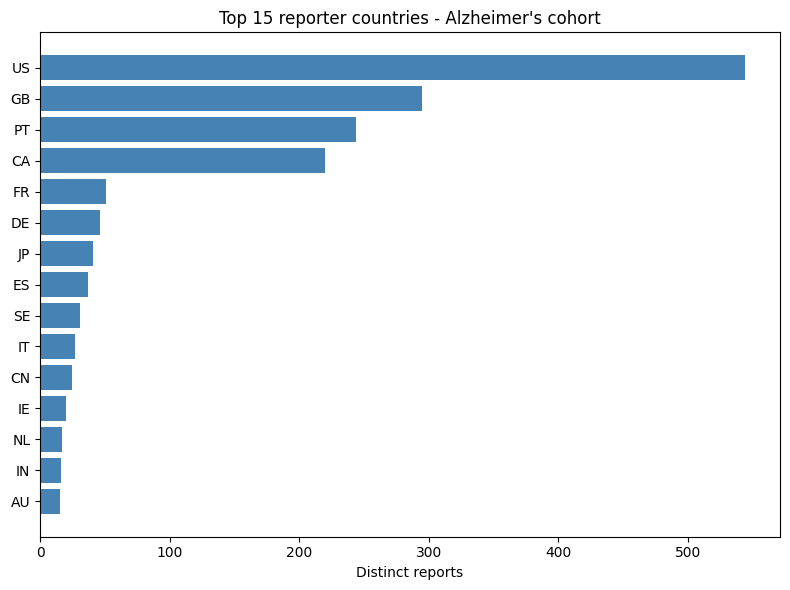

In [10]:
countries = pd.read_sql_query("""
    SELECT d.reporter_country,
           COUNT(DISTINCT d.primaryid) AS reports
    FROM demo d
    JOIN (SELECT DISTINCT primaryid FROM alzheimers_analysis) a
        ON d.primaryid = a.primaryid
    WHERE d.reporter_country IS NOT NULL
    GROUP BY d.reporter_country
    ORDER BY reports DESC
    LIMIT 15
""", conn)

plt.figure(figsize=(8, 6))
plt.barh(countries['reporter_country'], countries['reports'], color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel('Distinct reports')
plt.title('Top 15 reporter countries - Alzheimer\'s cohort')
plt.tight_layout()
plt.show()